In [1]:
import astropy.units as u
import astropy.coordinates as apycoords
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
hclu = pd.read_csv("/Volumes/newpassport/litclusterdatabases/HR24/HR24_clusters.csv")
hmem = pd.read_hdf("/Volumes/newpassport/litclusterdatabases/HR24/HR24_members.h5")


open_cond = (
    (hclu.dist16 < 500) & (hclu.CST > 5) & (hclu.Type == "o") & (hclu.RV.notna())
)
mg_cond = (hclu.dist16 < 500) & (hclu.CST > 10) & (hclu.Type == "m") & (hclu.RV.notna())
cond = open_cond | mg_cond

hclu = hclu.loc[cond].reset_index(drop=True).copy()

hmem = hmem.loc[hmem.Name.isin(hclu.Name)].reset_index(drop=True).copy()

In [13]:
def xyzuvw(ra, dec, parallax, pmra, pmdec, radial_velocity):
    """
    Converts ICRS ra (deg), dec (deg), parallax (mas), pmra (mas/yr),
    pmdec (mas/yr), and radial velocity (km/s) to heliocentric
    Cartesian XYZ (pc) and UVW (km/s)

    Args:
        ra (array-like): Right ascension in degrees
        dec (array-like): Declination in degrees
        parallax (array-like): Parallax in milliarcseconds
        pmra (array-like): Proper motion in right ascension (mas/yr)
        pmdec (array-like): Proper motion in declination (mas/yr)
        radial_velocity (array-like): Radial velocity in km/s

    Returns:
        numpy.ndarray : (n x 6) XYZUVW array
    """

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=(1000.0 / parallax) * u.pc,
        pm_ra_cosdec=pmra * u.mas / u.yr,
        pm_dec=pmdec * u.mas / u.yr,
        radial_velocity=radial_velocity * u.km / u.s,
        frame="icrs",
    )

    cg = c.transform_to(apycoords.Galactic())
    cg.representation_type = "cartesian"

    xyz = cg.cartesian.xyz.value.T.reshape(-1, 3)
    uvw = np.vstack([cg.U.value, cg.V.value, cg.W.value]).T
    xyzuvw = np.concatenate([xyz, uvw], axis=1)

    return xyzuvw

In [14]:
def galcen_cyl(ra, dec, parallax, pmra, pmdec, radial_velocity):
    """
    Converts ICRS ra (deg), dec (deg), parallax (mas), pmra (mas/yr),
    pmdec (mas/yr), and radial velocity (km/s) to Galactocentric cylindrical coordinates
    rho (kpc), phi (deg), z (pc), v_rho (km/s), v_phi (km/s), v_z (km/s)

    LEFT-HANDED

    Args:
        ra (array-like): Right ascension in degrees
        dec (array-like): Declination in degrees
        parallax (array-like): Parallax in milliarcseconds
        pmra (array-like): Proper motion in right ascension (mas/yr)
        pmdec (array-like): Proper motion in declination (mas/yr)
        radial_velocity (array-like): Radial velocity in km/s

    Returns:
        numpy.ndarray: (n x 6) array of galactocentric cylindrical coordinates


    """

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=(1000.0 / parallax) * u.pc,
        pm_ra_cosdec=pmra * u.mas / u.yr,
        pm_dec=pmdec * u.mas / u.yr,
        radial_velocity=radial_velocity * u.km / u.s,
        frame="icrs",
    )

    v_sun = apycoords.CartesianDifferential([11.1, 245.0, 7.25] * u.km / u.s)
    gc_frame = apycoords.Galactocentric(
        galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc, galcen_v_sun=v_sun
    )

    gc = c.transform_to(gc_frame)
    gc.representation_type = "cylindrical"

    cyl_coord = np.vstack(
        [
            gc.rho.to(u.kpc).value,
            180 - gc.phi.degree,  # 180 - PHI ASTROPY CONVENTION
            gc.z.to(u.kpc).value,
            gc.d_rho.to(u.km / u.s).value,
            -(gc.d_phi * gc.rho)
            .to(u.km / u.s, equivalencies=u.dimensionless_angles())
            .value,  # FLIPPED SIGN FROM ASTROPY CONVENTION
            gc.d_z.to(u.km / u.s).value,
        ]
    ).T

    return cyl_coord

In [ ]:
def galcen_cyl_pos(ra, dec, parallax):
    """
    Converts ICRS ra (deg), dec (deg), parallax (mas)
    to Galactocentric cylindrical coordinates
    rho (kpc), phi (deg), z_cyl (pc)

    LEFT-HANDED

    Args:
        ra (array-like): Right ascension in degrees
        dec (array-like): Declination in degrees
        parallax (array-like): Parallax in milliarcseconds

    Returns:
        numpy.ndarray: (n x 3) array of galactocentric cylindrical coordinates


    """

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=(1000.0 / parallax) * u.pc,
        frame="icrs",
    )

    gc_frame = apycoords.Galactocentric(galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc)

    gc = c.transform_to(gc_frame)
    gc.representation_type = "cylindrical"

    cyl_coord = np.vstack(
        [
            gc.rho.to(u.kpc).value,
            180 - gc.phi.degree,  # 180 - PHI ASTROPY CONVENTION
            gc.z.to(u.pc).value,
        ]
    ).T

    return cyl_coord

In [16]:
def icrs_to_galactic_pm(ra, dec, pmra, pmdec, parallax=None, distance=None):
    """
    Convert ICRS (pmra, pmdec) to Galactic (pm_l_cosb, pm_b).

    Parameters
    ----------
    ra, dec : float or array-like
        ICRS coordinates in degrees.
    pmra, pmdec : float or array-like
        Proper motions in ICRS frame (mas/yr).
        pmra is pm_ra_cosdec (i.e. already cos(dec)-corrected).
    parallax : float or array-like, optional
        Parallax in mas. Used to compute distance if `distance` not given.
    distance : float or array-like, optional
        Distance in pc. If None, derived from parallax.

    Returns
    -------
    pm_l_cosb, pm_b : ndarray
        Galactic proper motions in mas/yr.
    """
    if distance is not None:
        dist = np.asarray(distance) * u.pc
    elif parallax is not None:
        dist = (1000.0 / np.asarray(parallax)) * u.pc
    else:
        raise ValueError("Must provide either parallax or distance.")

    c = apycoords.SkyCoord(
        ra=np.asarray(ra) * u.deg,
        dec=np.asarray(dec) * u.deg,
        distance=dist,
        pm_ra_cosdec=np.asarray(pmra) * u.mas / u.yr,
        pm_dec=np.asarray(pmdec) * u.mas / u.yr,
        frame="icrs",
    )

    gal = c.galactic

    pm_l_cosb = gal.pm_l_cosb.to(u.mas / u.yr).value
    pm_b = gal.pm_b.to(u.mas / u.yr).value

    return pm_l_cosb, pm_b

In [ ]:
def skycoord_cylvel_ang_mom_to_dvT_old(
    ra, dec, parallax, pmra, pmdec, v_rho, v_phi, v_z, rho
):

    v_sun = apycoords.CartesianDifferential([11.1, 245.0, 7.25] * u.km / u.s)

    gc_frame = apycoords.Galactocentric(
        galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc, galcen_v_sun=v_sun
    )

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=(1000.0 / parallax) * u.pc,
        frame="icrs",
    )

    gc = c.transform_to(gc_frame)

    cyl = gc.represent_as(apycoords.CylindricalRepresentation)
    phi = cyl.phi

    v_rho = np.asarray(v_rho) * u.km / u.s

    v_phi = -np.asarray(v_phi) * u.km / u.s
    rho = np.asarray(rho) * u.kpc
    ang_mom = rho * v_phi

    v_z = np.asarray(v_z) * u.km / u.s

    rho_stars = galcen_cyl_pos(ra, dec, parallax)[:, 0] * u.kpc

    v_phi_pred = (ang_mom / rho_stars).to(u.km / u.s)

    vx = v_rho * np.cos(phi) - v_phi_pred * np.sin(phi)
    vy = v_rho * np.sin(phi) + v_phi_pred * np.cos(phi)
    vz = v_z

    gc_vel = apycoords.Galactocentric(
        x=gc.x,
        y=gc.y,
        z=gc.z,
        v_x=vx,
        v_y=vy,
        v_z=vz,
        galcen_distance=8.25 * u.kpc,
        z_sun=20.8 * u.pc,
        galcen_v_sun=v_sun,
    )

    icrs = apycoords.SkyCoord(gc_vel).transform_to(apycoords.ICRS())

    vra = 4.74047 * pmra / parallax
    vdec = 4.74047 * pmdec / parallax

    proj_pmra = icrs.pm_ra_cosdec.to(u.mas / u.yr).value
    proj_pmdec = icrs.pm_dec.to(u.mas / u.yr).value
    proj_vra = (
        (icrs.pm_ra_cosdec * icrs.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vdec = (
        (icrs.pm_dec * icrs.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vrad = icrs.radial_velocity.to(u.km / u.s).value

    gal = icrs.galactic
    proj_pm_l_cosb = gal.pm_l_cosb.to(u.mas / u.yr).value
    proj_pm_b = gal.pm_b.to(u.mas / u.yr).value

    delta_vra = vra - proj_vra
    delta_vdec = vdec - proj_vdec
    delta_vT = np.sqrt(delta_vra**2 + delta_vdec**2)

    return np.vstack(
        [vra, vdec, proj_vra, proj_vdec, proj_vrad, delta_vra, delta_vdec, delta_vT]
    ).T

In [20]:
clu_params = pd.read_csv("../data/clu_params.csv")

In [26]:
foo = skycoord_cylvel_ang_mom_to_dvT(
    clu_params.ra.values,
    clu_params.dec.values,
    clu_params.median_member_parallax.values,
    clu_params.pmra.values,
    clu_params.pmdec.values,
    clu_params.v_rho.values,
    clu_params.v_phi.values,
    clu_params.v_z.values,
    clu_params.rho.values,
)

In [27]:
foo[:, -3:]

array([[-1.93172854e-07,  1.95614778e-07,  2.74919794e-07],
       [ 9.59909174e-08, -1.28020983e-07,  1.60011338e-07],
       [-2.45315084e-07,  9.22574945e-08,  2.62089557e-07],
       [ 2.94771241e-06, -6.11637517e-07,  3.01049978e-06],
       [-7.32871763e-07,  1.82556242e-07,  7.55266710e-07],
       [-1.78723924e-07, -2.36719886e-07,  2.96611775e-07],
       [-1.29336270e-06,  2.87202302e-07,  1.32486687e-06],
       [ 1.26483067e-06, -1.53897627e-06,  1.99204533e-06],
       [ 2.84381366e-06, -4.69777202e-07,  2.88235438e-06],
       [-9.59111953e-07,  8.92772569e-07,  1.31032004e-06],
       [-2.99166909e-07,  1.62631992e-06,  1.65360737e-06],
       [-1.73530893e-06,  2.04517896e-07,  1.74731928e-06],
       [-1.61218104e-06,  4.82106970e-07,  1.68272245e-06],
       [ 9.76077336e-08,  2.03460108e-06,  2.03694104e-06],
       [ 1.15047253e-06, -1.31893501e-06,  1.75019331e-06],
       [ 1.24513763e-06, -9.07351891e-07,  1.54066712e-06],
       [ 2.87174456e-07,  2.89480277e-06

In [19]:
foo.shape

(288, 8)

In [2]:
import duckdb

In [22]:
df = duckdb.query("""
    SELECT * FROM '/Volumes/travelpassport/tables/allskylitjoin/sky_00000011.parquet'
    LIMIT 1000
""").df()

In [24]:
df.columns

Index(['source_id', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax',
       'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmra_error',
       'pmdec', 'pmdec_error', 'ruwe', 'phot_g_mean_flux',
       'phot_g_mean_flux_error', 'phot_g_mean_mag', 'phot_bp_mean_flux',
       'phot_bp_mean_flux_error', 'phot_bp_mean_mag', 'phot_rp_mean_flux',
       'phot_rp_mean_flux_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'bp_g', 'g_rp', 'radial_velocity',
       'radial_velocity_error', 'l', 'b', 'has_xp_continuous', 'has_rvs', 'X',
       'Y', 'Z', 'U', 'V', 'W', '__index_level_0__', 'source_id_1',
       'ocmg_name_1_SPYGLASS', 'ocmg_name_2_SPYGLASS', 'ocmg_name_3_SPYGLASS',
       'mem_prob_1_SPYGLASS', 'mem_prob_2_SPYGLASS', 'mem_prob_3_SPYGLASS',
       'ocmg_name_1_KCS20', 'ocmg_name_2_KCS20', 'ocmg_name_1_CG20',
       'ocmg_name_2_CG20', 'mem_prob_1_CG20', 'mem_prob_2_CG20',
       'ocmg_name_1_HR24', 'ocmg_name_2_HR24', 'ocmg_name_3_HR24',
       'mem

In [ ]:
df = duckdb.query("""
    SELECT * FROM '/Volumes/travelpassport/tables/spheres_cylvel/Collinder_350.parquet'
    WHERE delta_vT < 3
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [33]:
len(df)

2238889

<Axes: >

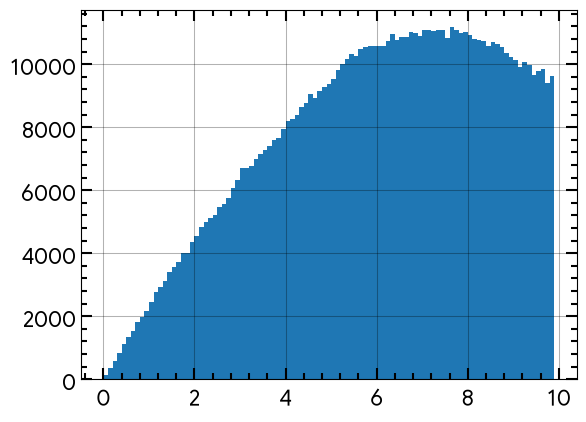

In [35]:
df.delta_vT.hist(bins=np.arange(0, 10, 0.1))

In [ ]:
df

In [36]:
import matplotlib.pyplot as plt

In [57]:
foo.columns

Index(['source_id', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax',
       'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmra_error',
       'pmdec', 'pmdec_error', 'ruwe', 'phot_g_mean_flux',
       'phot_g_mean_flux_error', 'phot_g_mean_mag', 'phot_bp_mean_flux',
       'phot_bp_mean_flux_error', 'phot_bp_mean_mag', 'phot_rp_mean_flux',
       'phot_rp_mean_flux_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'bp_g', 'g_rp', 'radial_velocity',
       'radial_velocity_error', 'l', 'b', 'has_xp_continuous', 'has_rvs', 'X',
       'Y', 'Z', 'U', 'V', 'W', 'ocmg_name_1_SPYGLASS', 'ocmg_name_2_SPYGLASS',
       'ocmg_name_3_SPYGLASS', 'mem_prob_1_SPYGLASS', 'mem_prob_2_SPYGLASS',
       'mem_prob_3_SPYGLASS', 'ocmg_name_1_KCS20', 'ocmg_name_2_KCS20',
       'ocmg_name_1_CG20', 'ocmg_name_2_CG20', 'mem_prob_1_CG20',
       'mem_prob_2_CG20', 'ocmg_name_1_HR24', 'ocmg_name_2_HR24',
       'ocmg_name_3_HR24', 'mem_prob_1_HR24', 'mem_prob_2_HR24',
       'm

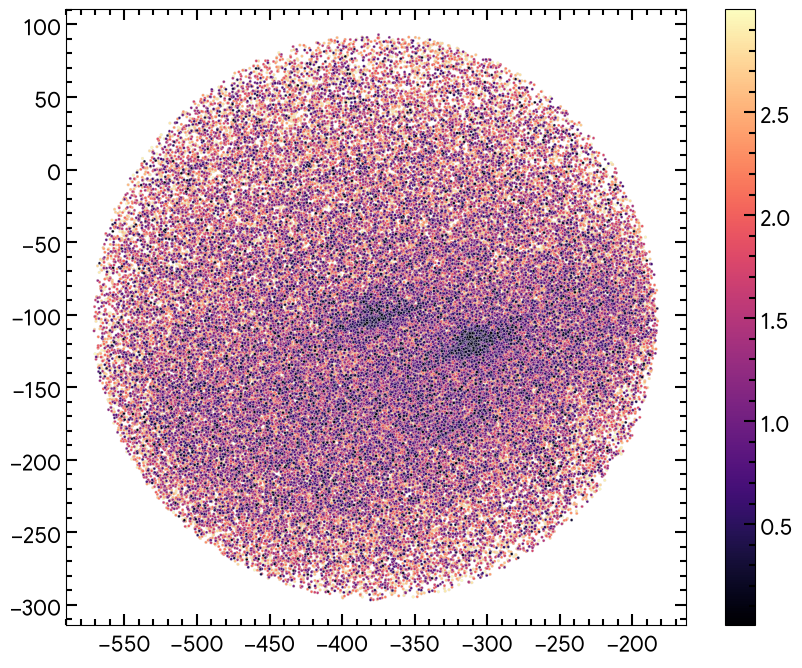

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

dvtlim = 2

foo = df.loc[df.delta_vT < dvtlim]

ix = np.flip(np.argsort(foo.delta_vT))
foo = foo.iloc[ix]

sc = ax.scatter(
    foo.X,
    foo.Y,
    # foo.g_rp,
    # foo.phot_g_mean_mag + 5 * np.log10(foo.parallax / 100),
    c=foo.delta_vT,
    cmap="magma",
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

# ax.invert_yaxis()
plt.colorbar(sc)

ax.set_aspect("equal", adjustable="datalim")
plt.show()

In [ ]:
df = duckdb.query("""
    SELECT * FROM '/Volumes/travelpassport/tables/spheres_with_name/Collinder_350.parquet'
    WHERE delta_vT < 3
""").df()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

dvtlim = 2

foo = df.loc[df.delta_vT < dvtlim]

ix = np.flip(np.argsort(foo.delta_vT))
foo = foo.iloc[ix]

sc = ax.scatter(
    foo.X,
    foo.Y,
    # foo.g_rp,
    # foo.phot_g_mean_mag + 5 * np.log10(foo.parallax / 100),
    c=foo.delta_vT,
    cmap="magma",
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

# ax.invert_yaxis()
plt.colorbar(sc)

ax.set_aspect("equal", adjustable="datalim")
plt.show()

In [ ]:
def skycoord_cylvel_ang_mom_to_dvT(
    ra, dec, parallax, pmra, pmdec, v_rho, v_phi, v_z, rho
):

    v_sun = apycoords.CartesianDifferential([11.1, 245.0, 7.25] * u.km / u.s)

    gc_frame = apycoords.Galactocentric(
        galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc, galcen_v_sun=v_sun
    )

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=(1000.0 / parallax) * u.pc,
        frame="icrs",
    )

    gc = c.transform_to(gc_frame)

    cyl = gc.represent_as(apycoords.CylindricalRepresentation)
    phi = cyl.phi

    v_rho = np.asarray(v_rho) * u.km / u.s
    v_phi = -np.asarray(v_phi) * u.km / u.s
    rho = np.asarray(rho) * u.kpc
    ang_mom = rho * v_phi

    v_z = np.asarray(v_z) * u.km / u.s

    rho_stars = galcen_cyl_pos(ra, dec, parallax)[:, 0] * u.kpc

    v_phi_pred = (ang_mom / rho_stars).to(u.km / u.s)

    vx = v_rho * np.cos(phi) - v_phi_pred * np.sin(phi)
    vy = v_rho * np.sin(phi) + v_phi_pred * np.cos(phi)
    vz = v_z

    gc_vel = apycoords.Galactocentric(
        x=gc.x,
        y=gc.y,
        z=gc.z,
        v_x=vx,
        v_y=vy,
        v_z=vz,
        galcen_distance=8.25 * u.kpc,
        z_sun=20.8 * u.pc,
        galcen_v_sun=v_sun,
    )

    icrs = apycoords.SkyCoord(gc_vel).transform_to(apycoords.ICRS())
    dist = (1000.0 / np.asarray(parallax)) * u.pc

    # ── ICRS residuals ───────────────────────────────────────────────────────
    vra = (
        (np.asarray(pmra) * u.mas / u.yr * dist)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    vdec = (
        (np.asarray(pmdec) * u.mas / u.yr * dist)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )

    proj_vra = (
        (icrs.pm_ra_cosdec * icrs.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vdec = (
        (icrs.pm_dec * icrs.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vrad = icrs.radial_velocity.to(u.km / u.s).value

    delta_vra = vra - proj_vra
    delta_vdec = vdec - proj_vdec
    delta_vT = np.sqrt(delta_vra**2 + delta_vdec**2)

    # ── Galactic proper motions & residuals ──────────────────────────────────
    pm_l_cosb_obs, pm_b_obs = icrs_to_galactic_pm(
        ra, dec, pmra, pmdec, parallax=parallax
    )

    vl_obs = (
        (pm_l_cosb_obs * u.mas / u.yr * dist)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    vb_obs = (
        (pm_b_obs * u.mas / u.yr * dist)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )

    gal_pred = icrs.galactic
    proj_vl = (
        (gal_pred.pm_l_cosb * gal_pred.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vb = (
        (gal_pred.pm_b * gal_pred.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )

    delta_vl = vl_obs - proj_vl
    delta_vb = vb_obs - proj_vb
    delta_vT_gal = np.sqrt(delta_vl**2 + delta_vb**2)

    return np.vstack(
        [
            vra,
            vdec,
            proj_vra,
            proj_vdec,
            proj_vrad,
            delta_vra,
            delta_vdec,
            delta_vT,
            pm_l_cosb_obs,
            pm_b_obs,
            vl_obs,
            vb_obs,
            proj_vl,
            proj_vb,
            delta_vl,
            delta_vb,
            delta_vT_gal,
        ]
    ).T